## 1. Setup and Imports

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# Transformers and embeddings
from sentence_transformers import SentenceTransformer, util

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Text analysis
from textblob import TextBlob

# Other utilities
import os
from collections import Counter
import re

# Configure plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully!")

# Create output directory
os.makedirs('../results/similarity', exist_ok=True)
print("✓ Output directory ready")

✓ All libraries imported successfully!
✓ Output directory ready


## 2. Download Required Resources

In [7]:
# Download NLTK data
print("Downloading NLTK resources...")
try:
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('averaged_perceptron_tagger', quiet=True)
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    print("✓ NLTK resources downloaded")
except Exception as e:
    print(f"⚠ NLTK download issue: {e}")

# Load Sentence-BERT model
print("\nLoading Sentence-BERT model...")
try:
    sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
    print("✓ Sentence-BERT model loaded: all-MiniLM-L6-v2")
    print("  - Fast and efficient")
    print("  - 384-dimensional embeddings")
    print("  - Trained on 1B+ sentence pairs")
except Exception as e:
    print(f"⚠ Model loading error: {e}")
    sbert_model = None

✓ NLTK resources downloaded

Loading Sentence-BERT model...
✓ NLTK resources downloaded

Loading Sentence-BERT model...
✓ Sentence-BERT model loaded: all-MiniLM-L6-v2
  - Fast and efficient
  - 384-dimensional embeddings
  - Trained on 1B+ sentence pairs


## 3. Input Sentences

Define the two sentences to compare.

In [5]:
# Input sentences
sentence1 = "The cat is sitting on the mat."
sentence2 = "A feline is resting on a rug."

# You can modify these sentences to test different comparisons
print("="*70)
print("SENTENCE COMPARISON")
print("="*70)
print(f"\nSentence 1: {sentence1}")
print(f"Sentence 2: {sentence2}")
print()

# Basic statistics
print("Basic Statistics:")
print("-" * 50)
print(f"  Sentence 1 length: {len(sentence1)} characters, {len(sentence1.split())} words")
print(f"  Sentence 2 length: {len(sentence2)} characters, {len(sentence2.split())} words")

SENTENCE COMPARISON

Sentence 1: The cat is sitting on the mat.
Sentence 2: A feline is resting on a rug.

Basic Statistics:
--------------------------------------------------
  Sentence 1 length: 30 characters, 7 words
  Sentence 2 length: 29 characters, 7 words


## 4. Text Preprocessing

In [8]:
def preprocess_text(text, remove_stopwords=False):
    """
    Preprocess text: tokenize, lowercase, lemmatize.
    """
    # Lowercase
    text = text.lower()
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove punctuation
    tokens = [token for token in tokens if token.isalnum()]
    
    # Remove stopwords (optional)
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [token for token in tokens if token not in stop_words]
    
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    return tokens

# Preprocess both sentences
tokens1 = preprocess_text(sentence1)
tokens2 = preprocess_text(sentence2)

tokens1_no_stop = preprocess_text(sentence1, remove_stopwords=True)
tokens2_no_stop = preprocess_text(sentence2, remove_stopwords=True)

print("Preprocessed Tokens:")
print("="*70)
print(f"\nSentence 1 tokens: {tokens1}")
print(f"Sentence 2 tokens: {tokens2}")
print(f"\nSentence 1 (no stopwords): {tokens1_no_stop}")
print(f"Sentence 2 (no stopwords): {tokens2_no_stop}")

Preprocessed Tokens:

Sentence 1 tokens: ['the', 'cat', 'is', 'sitting', 'on', 'the', 'mat']
Sentence 2 tokens: ['a', 'feline', 'is', 'resting', 'on', 'a', 'rug']

Sentence 1 (no stopwords): ['cat', 'sitting', 'mat']
Sentence 2 (no stopwords): ['feline', 'resting', 'rug']


## 5. Method 1: Sentence-BERT Semantic Similarity

Uses pre-trained transformer models to create sentence embeddings.

In [9]:
def calculate_sbert_similarity(sent1, sent2, model):
    """
    Calculate semantic similarity using Sentence-BERT.
    """
    if model is None:
        return None, None
    
    # Generate embeddings
    embedding1 = model.encode(sent1, convert_to_tensor=True)
    embedding2 = model.encode(sent2, convert_to_tensor=True)
    
    # Calculate cosine similarity
    similarity = util.cos_sim(embedding1, embedding2).item()
    
    return similarity, (embedding1, embedding2)

# Calculate SBERT similarity
sbert_score, sbert_embeddings = calculate_sbert_similarity(sentence1, sentence2, sbert_model)

print("="*70)
print("METHOD 1: SENTENCE-BERT SIMILARITY")
print("="*70)
if sbert_score is not None:
    print(f"\nSemantic Similarity Score: {sbert_score:.4f} ({sbert_score*100:.2f}%)")
    print(f"\nInterpretation:")
    if sbert_score >= 0.8:
        print("  ✓ Very High Similarity - Sentences are semantically very similar")
    elif sbert_score >= 0.6:
        print("  ✓ High Similarity - Sentences convey similar meaning")
    elif sbert_score >= 0.4:
        print("  ≈ Moderate Similarity - Some semantic overlap")
    elif sbert_score >= 0.2:
        print("  ✗ Low Similarity - Limited semantic connection")
    else:
        print("  ✗ Very Low Similarity - Sentences are semantically different")
    
    print(f"\nEmbedding dimensions: {sbert_embeddings[0].shape[0]}")
else:
    print("\n⚠ SBERT model not available")

METHOD 1: SENTENCE-BERT SIMILARITY

Semantic Similarity Score: 0.5395 (53.95%)

Interpretation:
  ≈ Moderate Similarity - Some semantic overlap

Embedding dimensions: 384


## 6. Method 2: TF-IDF + Cosine Similarity

Traditional vector space model approach.

In [10]:
def calculate_tfidf_similarity(sent1, sent2):
    """
    Calculate similarity using TF-IDF vectors.
    """
    # Create TF-IDF vectorizer
    vectorizer = TfidfVectorizer()
    
    # Create TF-IDF matrix
    tfidf_matrix = vectorizer.fit_transform([sent1, sent2])
    
    # Calculate cosine similarity
    similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
    
    # Get feature names and weights
    feature_names = vectorizer.get_feature_names_out()
    tfidf1 = tfidf_matrix[0].toarray()[0]
    tfidf2 = tfidf_matrix[1].toarray()[0]
    
    return similarity, (feature_names, tfidf1, tfidf2)

# Calculate TF-IDF similarity
tfidf_score, tfidf_data = calculate_tfidf_similarity(sentence1, sentence2)

print("="*70)
print("METHOD 2: TF-IDF COSINE SIMILARITY")
print("="*70)
print(f"\nTF-IDF Similarity Score: {tfidf_score:.4f} ({tfidf_score*100:.2f}%)")
print(f"\nVocabulary size: {len(tfidf_data[0])} unique terms")

# Show top terms
feature_names, tfidf1, tfidf2 = tfidf_data
print("\nTop terms by TF-IDF weight:")
print("  Sentence 1:")
for idx in np.argsort(tfidf1)[-5:][::-1]:
    if tfidf1[idx] > 0:
        print(f"    - {feature_names[idx]}: {tfidf1[idx]:.4f}")
print("  Sentence 2:")
for idx in np.argsort(tfidf2)[-5:][::-1]:
    if tfidf2[idx] > 0:
        print(f"    - {feature_names[idx]}: {tfidf2[idx]:.4f}")

METHOD 2: TF-IDF COSINE SIMILARITY

TF-IDF Similarity Score: 0.1786 (17.86%)

Vocabulary size: 9 unique terms

Top terms by TF-IDF weight:
  Sentence 1:
    - the: 0.7066
    - sitting: 0.3533
    - mat: 0.3533
    - cat: 0.3533
    - on: 0.2514
  Sentence 2:
    - rug: 0.4992
    - resting: 0.4992
    - feline: 0.4992
    - on: 0.3552
    - is: 0.3552


## 7. Method 3: Jaccard Similarity

Measures token overlap between sentences.

In [11]:
def calculate_jaccard_similarity(tokens1, tokens2):
    """
    Calculate Jaccard similarity between token sets.
    """
    set1 = set(tokens1)
    set2 = set(tokens2)
    
    intersection = set1.intersection(set2)
    union = set1.union(set2)
    
    similarity = len(intersection) / len(union) if len(union) > 0 else 0
    
    return similarity, intersection, union

# Calculate Jaccard similarity (with and without stopwords)
jaccard_score, intersection, union = calculate_jaccard_similarity(tokens1, tokens2)
jaccard_score_no_stop, intersection_no_stop, union_no_stop = calculate_jaccard_similarity(
    tokens1_no_stop, tokens2_no_stop
)

print("="*70)
print("METHOD 3: JACCARD SIMILARITY")
print("="*70)
print(f"\nJaccard Similarity (with stopwords): {jaccard_score:.4f} ({jaccard_score*100:.2f}%)")
print(f"Jaccard Similarity (no stopwords): {jaccard_score_no_stop:.4f} ({jaccard_score_no_stop*100:.2f}%)")

print(f"\nToken Analysis (with stopwords):")
print(f"  Common tokens: {intersection}")
print(f"  Unique to Sentence 1: {set(tokens1) - set(tokens2)}")
print(f"  Unique to Sentence 2: {set(tokens2) - set(tokens1)}")
print(f"  Total unique tokens: {len(union)}")

print(f"\nToken Analysis (no stopwords):")
print(f"  Common tokens: {intersection_no_stop}")
print(f"  Unique to Sentence 1: {set(tokens1_no_stop) - set(tokens2_no_stop)}")
print(f"  Unique to Sentence 2: {set(tokens2_no_stop) - set(tokens1_no_stop)}")

METHOD 3: JACCARD SIMILARITY

Jaccard Similarity (with stopwords): 0.2000 (20.00%)
Jaccard Similarity (no stopwords): 0.0000 (0.00%)

Token Analysis (with stopwords):
  Common tokens: {'on', 'is'}
  Unique to Sentence 1: {'the', 'sitting', 'mat', 'cat'}
  Unique to Sentence 2: {'a', 'feline', 'resting', 'rug'}
  Total unique tokens: 10

Token Analysis (no stopwords):
  Common tokens: set()
  Unique to Sentence 1: {'cat', 'sitting', 'mat'}
  Unique to Sentence 2: {'feline', 'resting', 'rug'}


## 8. Method 4: Linguistic Feature Analysis

Compare sentences based on linguistic properties.

In [12]:
def analyze_linguistic_features(sent1, sent2):
    """
    Analyze and compare linguistic features.
    """
    # Tokenize
    tokens1 = word_tokenize(sent1)
    tokens2 = word_tokenize(sent2)
    
    # POS tagging
    pos1 = pos_tag(tokens1)
    pos2 = pos_tag(tokens2)
    
    # Extract POS tag sequences
    pos_seq1 = [tag for _, tag in pos1]
    pos_seq2 = [tag for _, tag in pos2]
    
    # Sentiment analysis
    blob1 = TextBlob(sent1)
    blob2 = TextBlob(sent2)
    
    sentiment1 = blob1.sentiment
    sentiment2 = blob2.sentiment
    
    # Calculate POS similarity (Jaccard on POS tags)
    pos_similarity = len(set(pos_seq1).intersection(set(pos_seq2))) / \
                     len(set(pos_seq1).union(set(pos_seq2)))
    
    # Calculate sentiment similarity (inverse of difference)
    sentiment_diff = abs(sentiment1.polarity - sentiment2.polarity)
    sentiment_similarity = 1 - sentiment_diff
    
    # Length similarity
    len_ratio = min(len(tokens1), len(tokens2)) / max(len(tokens1), len(tokens2))
    
    features = {
        'pos1': pos1,
        'pos2': pos2,
        'pos_seq1': pos_seq1,
        'pos_seq2': pos_seq2,
        'pos_similarity': pos_similarity,
        'sentiment1': sentiment1,
        'sentiment2': sentiment2,
        'sentiment_similarity': sentiment_similarity,
        'length_similarity': len_ratio
    }
    
    return features

# Analyze linguistic features
features = analyze_linguistic_features(sentence1, sentence2)

print("="*70)
print("METHOD 4: LINGUISTIC FEATURE ANALYSIS")
print("="*70)

print(f"\n1. Part-of-Speech (POS) Analysis:")
print(f"   Sentence 1 POS: {features['pos1']}")
print(f"   Sentence 2 POS: {features['pos2']}")
print(f"   POS Similarity: {features['pos_similarity']:.4f} ({features['pos_similarity']*100:.2f}%)")

print(f"\n2. Sentiment Analysis:")
print(f"   Sentence 1 Sentiment: Polarity={features['sentiment1'].polarity:.3f}, Subjectivity={features['sentiment1'].subjectivity:.3f}")
print(f"   Sentence 2 Sentiment: Polarity={features['sentiment2'].polarity:.3f}, Subjectivity={features['sentiment2'].subjectivity:.3f}")
print(f"   Sentiment Similarity: {features['sentiment_similarity']:.4f} ({features['sentiment_similarity']*100:.2f}%)")

print(f"\n3. Length Similarity:")
print(f"   Similarity: {features['length_similarity']:.4f} ({features['length_similarity']*100:.2f}%)")

METHOD 4: LINGUISTIC FEATURE ANALYSIS

1. Part-of-Speech (POS) Analysis:
   Sentence 1 POS: [('The', 'DT'), ('cat', 'NN'), ('is', 'VBZ'), ('sitting', 'VBG'), ('on', 'IN'), ('the', 'DT'), ('mat', 'NN'), ('.', '.')]
   Sentence 2 POS: [('A', 'DT'), ('feline', 'NN'), ('is', 'VBZ'), ('resting', 'VBG'), ('on', 'IN'), ('a', 'DT'), ('rug', 'NN'), ('.', '.')]
   POS Similarity: 1.0000 (100.00%)

2. Sentiment Analysis:
   Sentence 1 Sentiment: Polarity=0.000, Subjectivity=0.000
   Sentence 2 Sentiment: Polarity=0.000, Subjectivity=0.000
   Sentiment Similarity: 1.0000 (100.00%)

3. Length Similarity:
   Similarity: 1.0000 (100.00%)


## 9. Comprehensive Similarity Score

Combine all methods into a weighted overall score.

In [13]:
def calculate_comprehensive_score(scores, weights=None):
    """
    Calculate weighted average of all similarity scores.
    """
    if weights is None:
        # Default weights (can be adjusted)
        weights = {
            'sbert': 0.35,           # Most important: semantic understanding
            'tfidf': 0.20,           # Term importance
            'jaccard': 0.15,         # Token overlap
            'pos': 0.10,             # Grammatical structure
            'sentiment': 0.10,       # Emotional tone
            'length': 0.10           # Length similarity
        }
    
    # Filter out None values
    valid_scores = {k: v for k, v in scores.items() if v is not None}
    
    # Normalize weights for valid scores
    total_weight = sum(weights[k] for k in valid_scores.keys())
    normalized_weights = {k: weights[k] / total_weight for k in valid_scores.keys()}
    
    # Calculate weighted score
    overall_score = sum(valid_scores[k] * normalized_weights[k] for k in valid_scores.keys())
    
    return overall_score, normalized_weights

# Compile all scores
all_scores = {
    'sbert': sbert_score,
    'tfidf': tfidf_score,
    'jaccard': jaccard_score_no_stop,  # Use without stopwords for content words
    'pos': features['pos_similarity'],
    'sentiment': features['sentiment_similarity'],
    'length': features['length_similarity']
}

# Calculate comprehensive score
overall_score, final_weights = calculate_comprehensive_score(all_scores)

print("="*70)
print("COMPREHENSIVE SIMILARITY ANALYSIS")
print("="*70)

print(f"\n{'='*70}")
print(f"OVERALL SIMILARITY SCORE: {overall_score:.4f} ({overall_score*100:.2f}%)")
print(f"{'='*70}")

print("\nSimilarity Factors Breakdown:")
print("-" * 70)
print(f"{'Factor':<25} {'Score':<15} {'Weight':<15} {'Contribution'}")
print("-" * 70)

factor_names = {
    'sbert': 'Semantic (SBERT)',
    'tfidf': 'TF-IDF Cosine',
    'jaccard': 'Token Overlap',
    'pos': 'Grammatical Structure',
    'sentiment': 'Sentiment',
    'length': 'Length'
}

for key in all_scores:
    if all_scores[key] is not None:
        score = all_scores[key]
        weight = final_weights[key]
        contribution = score * weight
        print(f"{factor_names[key]:<25} {score*100:>6.2f}% {weight*100:>13.1f}% {contribution*100:>13.2f}%")

print("-" * 70)

# Interpretation
print("\nInterpretation:")
if overall_score >= 0.8:
    interpretation = "✓ VERY HIGH SIMILARITY - Sentences are semantically equivalent"
elif overall_score >= 0.6:
    interpretation = "✓ HIGH SIMILARITY - Sentences convey very similar meaning"
elif overall_score >= 0.4:
    interpretation = "≈ MODERATE SIMILARITY - Sentences have notable semantic overlap"
elif overall_score >= 0.2:
    interpretation = "✗ LOW SIMILARITY - Limited semantic connection"
else:
    interpretation = "✗ VERY LOW SIMILARITY - Sentences are semantically distinct"

print(f"  {interpretation}")

COMPREHENSIVE SIMILARITY ANALYSIS

OVERALL SIMILARITY SCORE: 0.5245 (52.45%)

Similarity Factors Breakdown:
----------------------------------------------------------------------
Factor                    Score           Weight          Contribution
----------------------------------------------------------------------
Semantic (SBERT)           53.95%          35.0%         18.88%
TF-IDF Cosine              17.86%          20.0%          3.57%
Token Overlap               0.00%          15.0%          0.00%
Grammatical Structure     100.00%          10.0%         10.00%
Sentiment                 100.00%          10.0%         10.00%
Length                    100.00%          10.0%         10.00%
----------------------------------------------------------------------

Interpretation:
  ≈ MODERATE SIMILARITY - Sentences have notable semantic overlap


## 10. Visualizations

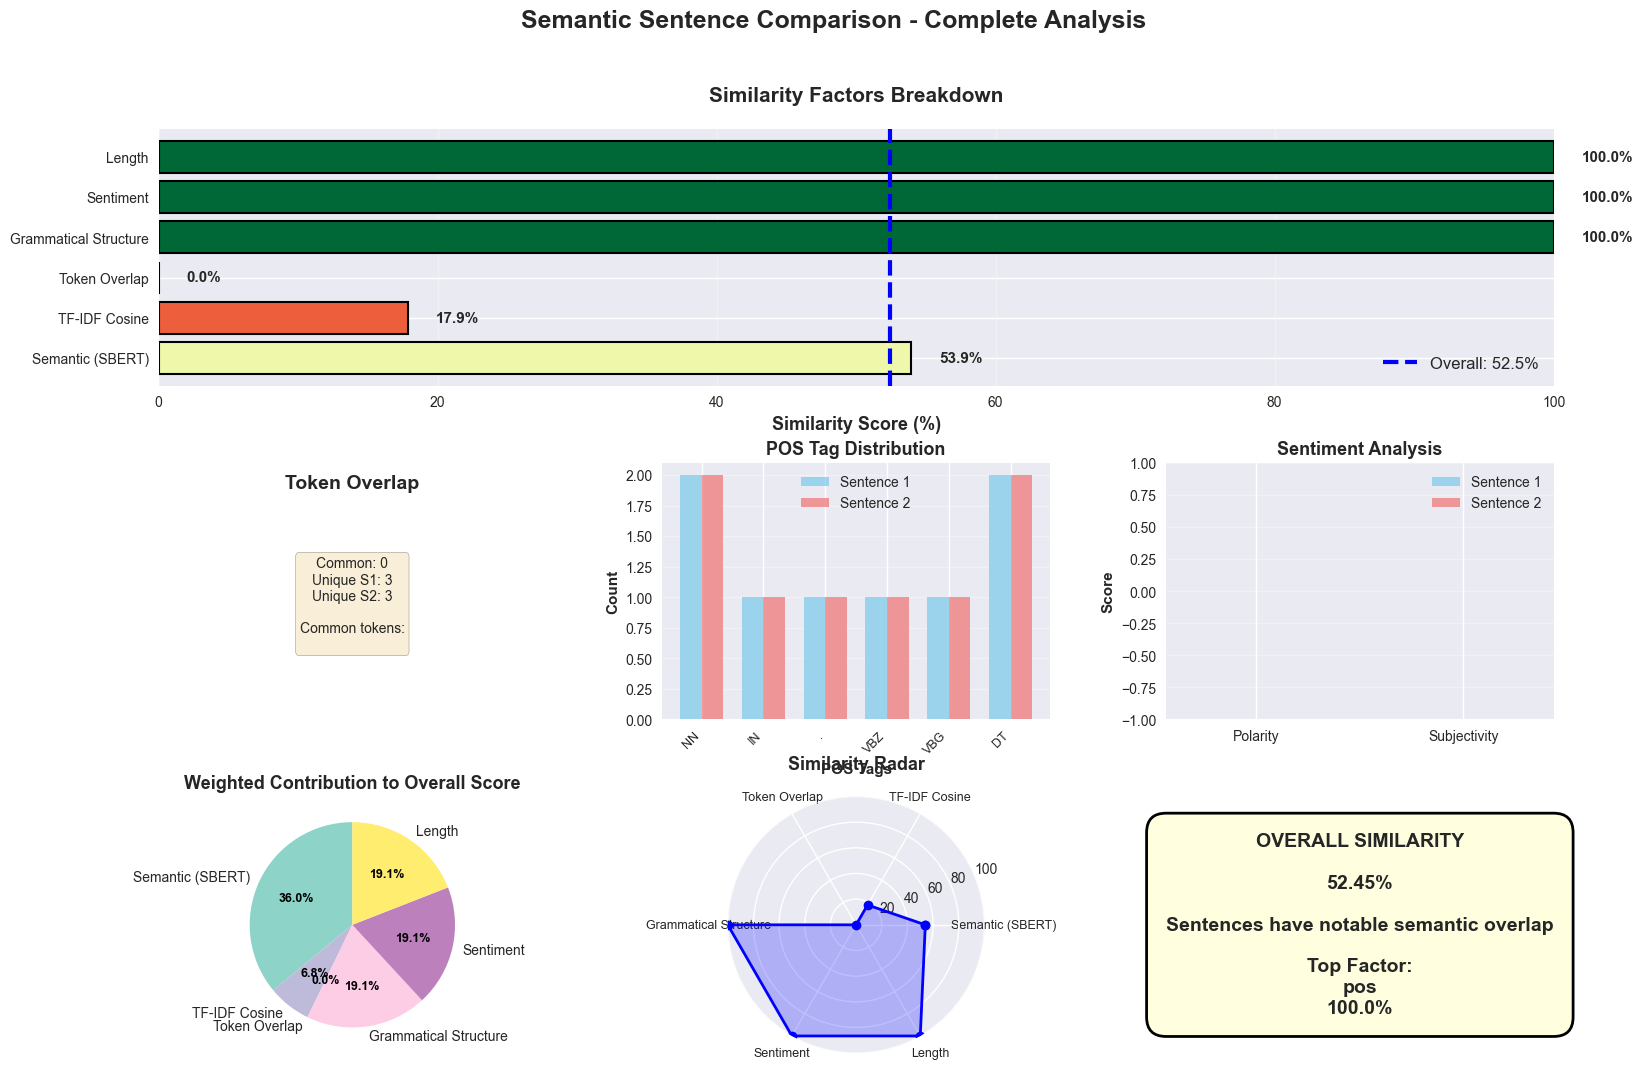


✓ Visualizations created


In [14]:
# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Overall Score Gauge
ax1 = fig.add_subplot(gs[0, :])
categories = list(factor_names.values())
scores = [all_scores[k]*100 if all_scores[k] is not None else 0 for k in all_scores.keys()]
colors = plt.cm.RdYlGn([s/100 for s in scores])

bars = ax1.barh(categories, scores, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Similarity Score (%)', fontsize=13, fontweight='bold')
ax1.set_title('Similarity Factors Breakdown', fontsize=15, fontweight='bold', pad=20)
ax1.set_xlim([0, 100])
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, score in zip(bars, scores):
    width = bar.get_width()
    ax1.text(width + 2, bar.get_y() + bar.get_height()/2, 
             f'{score:.1f}%', ha='left', va='center', fontsize=11, fontweight='bold')

# Add overall score
ax1.axvline(x=overall_score*100, color='blue', linestyle='--', linewidth=3, 
           label=f'Overall: {overall_score*100:.1f}%')
ax1.legend(fontsize=12, loc='lower right')

# 2. Token Overlap Venn Diagram (conceptual)
ax2 = fig.add_subplot(gs[1, 0])
ax2.axis('off')
ax2.text(0.5, 0.9, 'Token Overlap', ha='center', fontsize=14, fontweight='bold', 
         transform=ax2.transAxes)

overlap_text = f"Common: {len(intersection_no_stop)}\n"
overlap_text += f"Unique S1: {len(set(tokens1_no_stop) - set(tokens2_no_stop))}\n"
overlap_text += f"Unique S2: {len(set(tokens2_no_stop) - set(tokens1_no_stop))}\n\n"
overlap_text += f"Common tokens:\n{', '.join(list(intersection_no_stop)[:5])}"

ax2.text(0.5, 0.45, overlap_text, ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         transform=ax2.transAxes)

# 3. POS Distribution
ax3 = fig.add_subplot(gs[1, 1])
pos_counter1 = Counter([tag for _, tag in features['pos1']])
pos_counter2 = Counter([tag for _, tag in features['pos2']])
all_pos_tags = list(set(list(pos_counter1.keys()) + list(pos_counter2.keys())))

pos1_counts = [pos_counter1.get(tag, 0) for tag in all_pos_tags]
pos2_counts = [pos_counter2.get(tag, 0) for tag in all_pos_tags]

x = np.arange(len(all_pos_tags))
width = 0.35

ax3.bar(x - width/2, pos1_counts, width, label='Sentence 1', alpha=0.8, color='skyblue')
ax3.bar(x + width/2, pos2_counts, width, label='Sentence 2', alpha=0.8, color='lightcoral')
ax3.set_xlabel('POS Tags', fontsize=11, fontweight='bold')
ax3.set_ylabel('Count', fontsize=11, fontweight='bold')
ax3.set_title('POS Tag Distribution', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(all_pos_tags, rotation=45, ha='right', fontsize=9)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Sentiment Comparison
ax4 = fig.add_subplot(gs[1, 2])
sentiment_data = {
    'Sentence 1': [features['sentiment1'].polarity, features['sentiment1'].subjectivity],
    'Sentence 2': [features['sentiment2'].polarity, features['sentiment2'].subjectivity]
}
x_sent = np.arange(2)
width_sent = 0.35

ax4.bar(x_sent - width_sent/2, sentiment_data['Sentence 1'], width_sent, 
       label='Sentence 1', alpha=0.8, color='skyblue')
ax4.bar(x_sent + width_sent/2, sentiment_data['Sentence 2'], width_sent, 
       label='Sentence 2', alpha=0.8, color='lightcoral')
ax4.set_ylabel('Score', fontsize=11, fontweight='bold')
ax4.set_title('Sentiment Analysis', fontsize=13, fontweight='bold')
ax4.set_xticks(x_sent)
ax4.set_xticklabels(['Polarity', 'Subjectivity'])
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim([-1, 1])

# 5. Weighted Contribution Pie Chart
ax5 = fig.add_subplot(gs[2, 0])
contributions = [all_scores[k] * final_weights[k] * 100 for k in all_scores.keys() if all_scores[k] is not None]
labels_pie = [factor_names[k] for k in all_scores.keys() if all_scores[k] is not None]
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(contributions)))

wedges, texts, autotexts = ax5.pie(contributions, labels=labels_pie, autopct='%1.1f%%',
                                    colors=colors_pie, startangle=90)
ax5.set_title('Weighted Contribution to Overall Score', fontsize=13, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

# 6. Score Comparison Radar (if possible)
ax6 = fig.add_subplot(gs[2, 1], projection='polar')
categories_radar = list(factor_names.values())
scores_radar = [all_scores[k]*100 if all_scores[k] is not None else 0 for k in all_scores.keys()]
N = len(categories_radar)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
scores_radar += scores_radar[:1]
angles += angles[:1]

ax6.plot(angles, scores_radar, 'o-', linewidth=2, color='blue', label='Scores')
ax6.fill(angles, scores_radar, alpha=0.25, color='blue')
ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(categories_radar, fontsize=9)
ax6.set_ylim(0, 100)
ax6.set_title('Similarity Radar', fontsize=13, fontweight='bold', pad=20)
ax6.grid(True)

# 7. Summary Box
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
summary_text = f"OVERALL SIMILARITY\n\n"
summary_text += f"{overall_score*100:.2f}%\n\n"
summary_text += f"{interpretation.split('-')[1].strip()}\n\n"
summary_text += f"Top Factor:\n{max(all_scores, key=lambda k: all_scores[k] if all_scores[k] else 0)}\n"
summary_text += f"{max([s for s in all_scores.values() if s is not None])*100:.1f}%"

# Color based on score
if overall_score >= 0.7:
    box_color = 'lightgreen'
elif overall_score >= 0.4:
    box_color = 'lightyellow'
else:
    box_color = 'lightcoral'

ax7.text(0.5, 0.5, summary_text, ha='center', va='center', fontsize=14, fontweight='bold',
         bbox=dict(boxstyle='round,pad=1', facecolor=box_color, edgecolor='black', linewidth=2),
         transform=ax7.transAxes)

plt.suptitle('Semantic Sentence Comparison - Complete Analysis', 
             fontsize=18, fontweight='bold', y=0.98)

plt.savefig('../results/similarity/comprehensive_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Visualizations created")

## 11. Save Results

In [15]:
# Create detailed results DataFrame
results_df = pd.DataFrame([
    {
        'Factor': factor_names[k],
        'Score': f"{all_scores[k]*100:.2f}%" if all_scores[k] is not None else 'N/A',
        'Weight': f"{final_weights[k]*100:.1f}%" if k in final_weights else 'N/A',
        'Contribution': f"{all_scores[k] * final_weights[k] * 100:.2f}%" if all_scores[k] and k in final_weights else 'N/A'
    }
    for k in all_scores.keys()
])

# Add overall row
results_df = pd.concat([results_df, pd.DataFrame([{
    'Factor': 'OVERALL',
    'Score': f"{overall_score*100:.2f}%",
    'Weight': '100.0%',
    'Contribution': f"{overall_score*100:.2f}%"
}])], ignore_index=True)

# Save to CSV
results_df.to_csv('../results/similarity/similarity_scores.csv', index=False)
print("✓ Results saved to CSV")

# Save detailed report
report_path = '../results/similarity/similarity_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("SEMANTIC SENTENCE COMPARISON REPORT\n")
    f.write("="*70 + "\n\n")
    
    f.write("INPUT SENTENCES:\n")
    f.write("-" * 70 + "\n")
    f.write(f"Sentence 1: {sentence1}\n")
    f.write(f"Sentence 2: {sentence2}\n\n")
    
    f.write("OVERALL SIMILARITY SCORE:\n")
    f.write("-" * 70 + "\n")
    f.write(f"{overall_score*100:.2f}%\n")
    f.write(f"Interpretation: {interpretation}\n\n")
    
    f.write("SIMILARITY FACTORS BREAKDOWN:\n")
    f.write("-" * 70 + "\n")
    f.write(results_df.to_string(index=False))
    f.write("\n\n")
    
    f.write("DETAILED ANALYSIS:\n")
    f.write("-" * 70 + "\n")
    f.write(f"\n1. Semantic Similarity (SBERT): {sbert_score*100:.2f}%" if sbert_score else "\n1. Semantic Similarity: N/A\n")
    f.write(f"\n2. TF-IDF Cosine Similarity: {tfidf_score*100:.2f}%\n")
    f.write(f"\n3. Token Overlap (Jaccard): {jaccard_score_no_stop*100:.2f}%\n")
    f.write(f"   Common tokens: {', '.join(intersection_no_stop)}\n")
    f.write(f"\n4. Grammatical Structure (POS): {features['pos_similarity']*100:.2f}%\n")
    f.write(f"\n5. Sentiment Similarity: {features['sentiment_similarity']*100:.2f}%\n")
    f.write(f"   Sentence 1: Polarity={features['sentiment1'].polarity:.3f}, Subjectivity={features['sentiment1'].subjectivity:.3f}\n")
    f.write(f"   Sentence 2: Polarity={features['sentiment2'].polarity:.3f}, Subjectivity={features['sentiment2'].subjectivity:.3f}\n")
    f.write(f"\n6. Length Similarity: {features['length_similarity']*100:.2f}%\n")
    
    f.write("\n" + "="*70 + "\n")

print(f"✓ Detailed report saved to: {report_path}")

# Display summary
print("\n" + "="*70)
print("RESULTS SUMMARY")
print("="*70)
print(f"\nOverall Similarity: {overall_score*100:.2f}%")
print(f"\n{results_df.to_string(index=False)}")
print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE!")
print("="*70)

✓ Results saved to CSV
✓ Detailed report saved to: ../results/similarity/similarity_report.txt

RESULTS SUMMARY

Overall Similarity: 52.45%

               Factor   Score Weight Contribution
     Semantic (SBERT)  53.95%  35.0%       18.88%
        TF-IDF Cosine  17.86%  20.0%        3.57%
        Token Overlap   0.00%  15.0%          N/A
Grammatical Structure 100.00%  10.0%       10.00%
            Sentiment 100.00%  10.0%       10.00%
               Length 100.00%  10.0%       10.00%
              OVERALL  52.45% 100.0%       52.45%

✅ ANALYSIS COMPLETE!


## 12. Interactive Testing

Try different sentence pairs to compare.

In [16]:
# Example test cases
test_cases = [
    (
        "The cat is sitting on the mat.",
        "A feline is resting on a rug."
    ),
    (
        "I love programming in Python.",
        "Python is my favorite programming language."
    ),
    (
        "The weather is sunny today.",
        "I enjoy eating pizza for dinner."
    ),
    (
        "Machine learning is fascinating.",
        "Artificial intelligence is interesting."
    ),
    (
        "The quick brown fox jumps over the lazy dog.",
        "A fast auburn fox leaps above an idle canine."
    )
]

print("="*70)
print("QUICK TEST CASES")
print("="*70)

for i, (sent1, sent2) in enumerate(test_cases, 1):
    print(f"\nTest Case {i}:")
    print(f"  S1: {sent1}")
    print(f"  S2: {sent2}")
    
    # Quick SBERT score
    if sbert_model:
        quick_score, _ = calculate_sbert_similarity(sent1, sent2, sbert_model)
        print(f"  Similarity: {quick_score*100:.2f}%")
    print("-" * 70)

print("\n✓ Test cases completed")

QUICK TEST CASES

Test Case 1:
  S1: The cat is sitting on the mat.
  S2: A feline is resting on a rug.
  Similarity: 53.95%
----------------------------------------------------------------------

Test Case 2:
  S1: I love programming in Python.
  S2: Python is my favorite programming language.
  Similarity: 87.76%
----------------------------------------------------------------------

Test Case 3:
  S1: The weather is sunny today.
  S2: I enjoy eating pizza for dinner.
  Similarity: 8.81%
----------------------------------------------------------------------

Test Case 4:
  S1: Machine learning is fascinating.
  S2: Artificial intelligence is interesting.
  Similarity: 74.94%
----------------------------------------------------------------------

Test Case 5:
  S1: The quick brown fox jumps over the lazy dog.
  S2: A fast auburn fox leaps above an idle canine.
  Similarity: 87.76%
----------------------------------------------------------------------

Test Case 3:
  S1: The weather is